{'topic': '猫', 'joke': '为什么猫咪总是摆出一副“没睡醒”的样子？\n\n因为它们在努力地省着用自己的九条命啊！', 'story': '米娅是一只通体乌黑的猫，只有胸前有一小撮白毛，像夜空中唯一的一颗星。她拥有一双琥珀色的眼睛，总是闪烁着好奇与一丝不易察觉的狡黠。\n\n每天清晨，当第一缕阳光透过窗帘缝隙洒进房间时，米娅便会准时醒来。她优雅地伸展着身体，仿佛在进行一场无声的瑜伽，然后轻盈地跳上窗台。那里是她的王国，她会花上好一会儿，用那双锐利的眼睛观察窗外麻雀的动向，或者只是懒洋洋地打个盹，享受阳光的温暖。\n\n米娅的午后时光通常充满“探险”。她可能会悄无声息地穿梭于书架之间，用爪子轻轻拨弄书脊，仿佛在阅读；也可能突然对地毯上的一粒灰尘产生浓厚的兴趣，扑、抓、滚，玩得不亦乐乎。她的动作总是那么柔软而迅捷，像一道黑色的闪电。\n\n傍晚，当主人下班回家时，米娅会从某个隐蔽的角落里走出来，用她柔软的身体蹭蹭主人的腿，发出满足的“咕噜咕噜”声。她不爱撒娇，但这种无声的依偎，却比任何语言都更能表达她的爱意。主人会温柔地抚摸她乌黑发亮的皮毛，感受她身体传来的温暖。\n\n夜幕降临，米娅会蜷缩在主人脚边的小窝里，听着主人均匀的呼吸声，进入甜美的梦乡。在梦里，她也许还在追逐着窗外的麻雀，或者在广阔的草地上自由奔跑。\n\n米娅，这只安静而独立的黑猫，用她独特的方式，给这个家带来了无尽的温暖与陪伴。她不仅仅是一只宠物，更是这个家庭中不可或缺的，带着一丝神秘色彩的成员。', 'poem': '好的，这是一首关于猫的简短诗：\n\n**猫**\n\n一团绒毛，窝在阳光里，\n伸个懒腰，琥珀瞳孔亮。\n来去无声，步态多轻巧，\n家中小小，温柔的谜。', 'combined_output': '下面是一个关于“猫”的故事、笑话和诗歌！\n\n故事：\n米娅是一只通体乌黑的猫，只有胸前有一小撮白毛，像夜空中唯一的一颗星。她拥有一双琥珀色的眼睛，总是闪烁着好奇与一丝不易察觉的狡黠。\n\n每天清晨，当第一缕阳光透过窗帘缝隙洒进房间时，米娅便会准时醒来。她优雅地伸展着身体，仿佛在进行一场无声的瑜伽，然后轻盈地跳上窗台。那里是她的王国，她会花上好一会儿，用那双锐利的眼睛观察窗外麻雀的动向，或者只是懒洋洋地打个盹，享受阳光的温暖。\n\n米娅的午后时光通常充满“探险”。她可

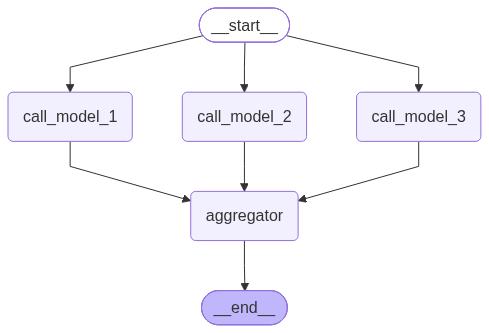

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	call_model_1(call_model_1)
	call_model_2(call_model_2)
	call_model_3(call_model_3)
	aggregator(aggregator)
	__end__([<p>__end__</p>]):::last
	__start__ --> call_model_1;
	__start__ --> call_model_2;
	__start__ --> call_model_3;
	call_model_1 --> aggregator;
	call_model_2 --> aggregator;
	call_model_3 --> aggregator;
	aggregator --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print as rprint

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

# 节点
def call_model_1(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短的笑话")]
    )
    return {"joke": msg.content}

def call_model_2(state: OverAllState) -> OverAllState:
    """第二次调用大模型，生成故事"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短的故事")]
    )
    return {"story": msg.content}

def call_model_3(state: OverAllState) -> OverAllState:
    """第三次调用大模型，生成诗歌"""

    msg = model.invoke(
        [HumanMessage(content=f"写一首关于“{state['topic']}”的简短的诗")]
    )
    return {"poem": msg.content}

def aggregator(state: OverAllState) -> OverAllState:
    """将笑话、故事和诗歌合并为单一输出"""

    combined = f"下面是一个关于“{state['topic']}”的故事、笑话和诗歌！\n\n"
    combined += f"故事：\n{state['story']}\n\n"
    combined += f"笑话：\n{state['joke']}\n\n"
    combined += f"诗歌：\n{state['poem']}"
    return {"combined_output": combined}

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("call_model_1", call_model_1)
builder.add_node("call_model_2", call_model_2)
builder.add_node("call_model_3", call_model_3)
builder.add_node("aggregator", aggregator)

# 添加边，连接各个节点
builder.add_edge(START, "call_model_1")
builder.add_edge(START, "call_model_2")
builder.add_edge(START, "call_model_3")
builder.add_edge(["call_model_1", "call_model_2", "call_model_3"], "aggregator")
builder.add_edge("aggregator", END)

graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)